In [1]:
# This notebook investigates and visualizes the training of trajectory model, while experimenting the effect of coupling and decoupling distribution \pi
import numpy as np 
import torch.nn as nn 
from sklearn.datasets import make_swiss_roll,\
     make_moons, make_gaussian_quantiles, make_circles, make_blobs 
import torch 
import matplotlib.pyplot as plt 
import matplotlib.animation as animation


In [2]:
# quite simple flow model 
class FlowModel(nn.Module):
  def __init__(self, input_dim, ffn_dim, output_dim):
    super(FlowModel, self).__init__() 
    self.input_dim = input_dim 
    self.output_dim = output_dim 
    self.ffn_dim = ffn_dim 
    self.model = nn.Sequential(
      nn.Linear(input_dim + 1, ffn_dim), 
      nn.ELU(), 
      nn.Linear(ffn_dim, ffn_dim), 
      nn.ELU(), 
      nn.Linear(ffn_dim, ffn_dim), 
      nn.ELU(), 
      nn.Linear(ffn_dim, output_dim)
    )
  
  def forward(self, x_t, t): 
    return self.model(torch.cat((x_t, t), dim = -1))

  def step(self, x_t, t_0, t_1):
   t_0 = t_0.view(1, 1).expand(x_t.shape[0], 1) 
   return x_t + (t_1 - t_0) * self(x_t = x_t, t = t_0)  #self(t = t_0 + (t_1 - t_0) / 2, x_t = x_t + self(x_t = x_t, t = t_0) * (t_1 - t_0) / 2)

In [3]:
'''
Borrowed from :
https://github.com/helblazer811/Diffusion-Explorer/blob/0dcfab92b2898f77553257c3642eb8c3aaf31f9a/diffusion-explor\
    er/apps/continuity-equation-explainer/scripts/generate_smiley_face.py#L15
'''
def make_smiley_face(num_samples: int = 400) -> np.ndarray:
    """
    Create smiley face distribution by sampling from Gaussians.

    - Eyes: Two Gaussians at top of face (negative y in screen coords)
    - Nose: Single Gaussian in center
    - Mouth: Sequence of Gaussians along a curved arc at bottom (positive y)

    Returns array of shape (num_samples, 2).
    """
    samples = []

    # Feature parameters (will be scaled up at the end)
    eye_std = 0.04   # Tighter eyes
    nose_std = 0.04  # Tighter nose
    mouth_std = 0.04  # Tighter mouth

    # Positions (y negative = top, y positive = bottom in screen coords)
    # Eyes closer together
    left_eye_pos = np.array([-0.35, -0.6])
    right_eye_pos = np.array([0.35, -0.6])
    nose_pos = np.array([0.0, -0.15])  # Shifted up (more negative y)

    # Mouth arc parameters
    mouth_center_y = 0.5  # Center of mouth arc
    mouth_radius = 0.6    # Radius of the arc
    mouth_arc_start = 0.2 * np.pi  # Start angle (radians from horizontal) - wider
    mouth_arc_end = 0.8 * np.pi    # End angle - wider
    num_mouth_gaussians = 12       # Number of Gaussians along the arc

    # Weights for each feature (determines proportion of samples)
    eye_weight = 1.0
    nose_weight = 0.5
    mouth_weight = 3.0  # More samples for the mouth since it's larger

    total_weight = 2 * eye_weight + nose_weight + mouth_weight

    # Calculate number of samples for each feature
    n_per_eye = int(num_samples * eye_weight / total_weight)
    n_nose = int(num_samples * nose_weight / total_weight)
    n_mouth = num_samples - 2 * n_per_eye - n_nose

    # Sample eyes
    left_eye_samples = np.random.normal(left_eye_pos, eye_std, (n_per_eye, 2))
    right_eye_samples = np.random.normal(right_eye_pos, eye_std, (n_per_eye, 2))
    samples.extend(left_eye_samples)
    samples.extend(right_eye_samples)

    # Sample nose
    nose_samples = np.random.normal(nose_pos, nose_std, (n_nose, 2))
    samples.extend(nose_samples)

    # Sample mouth along arc
    # Generate positions along the arc
    angles = np.linspace(mouth_arc_start, mouth_arc_end, num_mouth_gaussians)
    mouth_centers = []
    for angle in angles:
        x = mouth_radius * np.cos(angle)
        y = mouth_center_y + mouth_radius * np.sin(angle) - mouth_radius  # Shift down
        mouth_centers.append(np.array([x, y]))

    # Sample from each mouth Gaussian
    samples_per_mouth_gaussian = n_mouth // num_mouth_gaussians
    remainder = n_mouth % num_mouth_gaussians

    for i, center in enumerate(mouth_centers):
        n = samples_per_mouth_gaussian + (1 if i < remainder else 0)
        mouth_samples = np.random.normal(center, mouth_std, (n, 2))
        samples.extend(mouth_samples)

    samples = np.array(samples)

    # Mean center the samples
    mean = samples.mean(axis=0)
    samples = samples - mean
    std = samples.std()
    samples = samples / std

    scale_factor = 1.4
    samples = samples * scale_factor

    return samples * (-1)

def get_dataset_samples(dataset = 'blobs', n_samples = 2000, random_state = 42, **kwargs):
 defaults = {
  'blobs' : dict(n_features = 2, centers = 3, cluster_std = 0.5),
  'moons' : dict(noise = 0.05),
  'circles': dict(noise = 0.05, factor = 0.5),
  'swiss_roll': dict(noise = 0.1),
  'gaussian_quantiles':  dict(n_features = 2, n_classes = 3),
 }

 makers = {
  'blobs':              make_blobs,
  'moons':              make_moons,
  'circles':            make_circles,
  'swiss_roll':         make_swiss_roll,
  'gaussian_quantiles': make_gaussian_quantiles,
 }

 if dataset not in makers:
  raise ValueError(f"Unknown dataset '{dataset}'. "
                         f"Choose from: {list(makers.keys())}")

 params = {**defaults[dataset], **kwargs}
 X, y = makers[dataset](n_samples=n_samples, random_state=random_state, **params)

    # swiss_roll returns 3D; keep only the 2 spread dimensions
 if dataset == 'swiss_roll':
   X = X[:, [0, 2]]

 X = torch.tensor(X, dtype = torch.float32)
 y = torch.tensor(y, dtype = torch.long)
 return X, y 

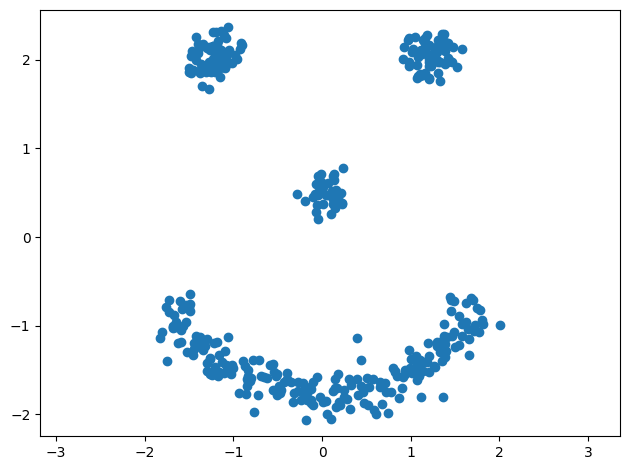

In [4]:
samples = make_smiley_face()

plt.scatter(samples[:, 0], samples[:, 1])
plt.axis("equal")
plt.tight_layout()
plt.show()

In [5]:
net = FlowModel(input_dim = 2, output_dim = 2, ffn_dim = 64)
optimizer = torch.optim.Adam(net.parameters(), lr = 1e-2)
num_epochs = 10000
loss_fn   = nn.MSELoss()
n_samples = 2000 
n_features = 2
random_state = 42
cluster_std = 0.5 
centers = 3


# Training decouple flow (independent) 
for i in range(num_epochs):
    x_1 = torch.tensor(make_smiley_face(n_samples), dtype = torch.float32)
    
    t = torch.rand(len(x_1), 1)
    x_0 = torch.randn_like(x_1)
    x_t = x_1 * t + x_0 * (1 - t)
    dx_t     = x_1 - x_0
    optimizer.zero_grad()
    net_out  = net(x_t, t)
    loss     = loss_fn(net_out, dx_t)
    loss.backward()
    optimizer.step()

    if i % 100 == 0: 
       print(f"step {i} | loss: {loss.item():.4f}")



step 0 | loss: 2.9447
step 100 | loss: 1.8660
step 200 | loss: 1.7975
step 300 | loss: 1.8751
step 400 | loss: 1.8261
step 500 | loss: 1.8463
step 600 | loss: 1.8685
step 700 | loss: 1.7723
step 800 | loss: 1.8090
step 900 | loss: 1.8482
step 1000 | loss: 1.8388
step 1100 | loss: 1.8218
step 1200 | loss: 1.8522
step 1300 | loss: 1.7534
step 1400 | loss: 1.6982
step 1500 | loss: 1.8371
step 1600 | loss: 1.8433
step 1700 | loss: 1.8007
step 1800 | loss: 1.8313
step 1900 | loss: 1.8520
step 2000 | loss: 1.7523
step 2100 | loss: 1.8836
step 2200 | loss: 1.8186
step 2300 | loss: 1.8992
step 2400 | loss: 1.7367
step 2500 | loss: 1.8540
step 2600 | loss: 1.7646
step 2700 | loss: 1.9211
step 2800 | loss: 1.8312
step 2900 | loss: 1.8326
step 3000 | loss: 1.7926
step 3100 | loss: 1.8523
step 3200 | loss: 1.8216
step 3300 | loss: 1.7434
step 3400 | loss: 1.8832
step 3500 | loss: 1.7679
step 3600 | loss: 1.7516
step 3700 | loss: 1.8056
step 3800 | loss: 1.8196
step 3900 | loss: 1.7163
step 4000 | 

In [11]:
rectified_net = FlowModel(input_dim = 2, output_dim = 2, ffn_dim = 64)
rec_optimizer = torch.optim.Adam(rectified_net.parameters(), lr = 1e-2)
num_epochs = 10000
loss_fn   = nn.MSELoss()
n_samples = 2000
n_steps = 8 
time_steps = torch.linspace(0, 1.0, n_steps + 1)

def samples(x_0): 
  x = x_0
  with torch.no_grad():
    for i in range(n_steps):
      x = net.step(x, time_steps[i], time_steps[i + 1])
    return x 

# Training coupling flow (higher degree of dedependent) 
for i in range(num_epochs):
    #x_1 = torch.tensor(make_moons(n_samples = 2000, noise = 0.05)[0], dtype = torch.float32)
    t = torch.rand(len(x_1), 1)
    x_0 = torch.randn((n_samples, 2))
    x_1 = samples(x_0)
    x_t = x_0 * (1 - t) + t * x_1 
    dx_t     = x_1 - x_0
    rec_optimizer.zero_grad()
    rec_net_out  = rectified_net(x_t, t)
    loss = loss_fn(rec_net_out, dx_t)
    loss.backward()
    rec_optimizer.step()

    if i % 100 == 0: 
       print(f"step {i} | loss: {loss.item():.4f}")



step 0 | loss: 0.4171
step 100 | loss: 0.0634
step 200 | loss: 0.0210
step 300 | loss: 0.0158
step 400 | loss: 0.0121
step 500 | loss: 0.0083
step 600 | loss: 0.0072
step 700 | loss: 0.0094
step 800 | loss: 0.0065
step 900 | loss: 0.0060
step 1000 | loss: 0.0044
step 1100 | loss: 0.0056
step 1200 | loss: 0.0046
step 1300 | loss: 0.0051
step 1400 | loss: 0.0049
step 1500 | loss: 0.0026
step 1600 | loss: 0.0026
step 1700 | loss: 0.0020
step 1800 | loss: 0.0024
step 1900 | loss: 0.0034
step 2000 | loss: 0.0056
step 2100 | loss: 0.0022
step 2200 | loss: 0.0020
step 2300 | loss: 0.0023
step 2400 | loss: 0.0019
step 2500 | loss: 0.0046
step 2600 | loss: 0.0017
step 2700 | loss: 0.0020
step 2800 | loss: 0.0017
step 2900 | loss: 0.0026
step 3000 | loss: 0.0042
step 3100 | loss: 0.0023
step 3200 | loss: 0.0028
step 3300 | loss: 0.0012
step 3400 | loss: 0.0017
step 3500 | loss: 0.0015
step 3600 | loss: 0.0017
step 3700 | loss: 0.0012
step 3800 | loss: 0.0016
step 3900 | loss: 0.0012
step 4000 | 

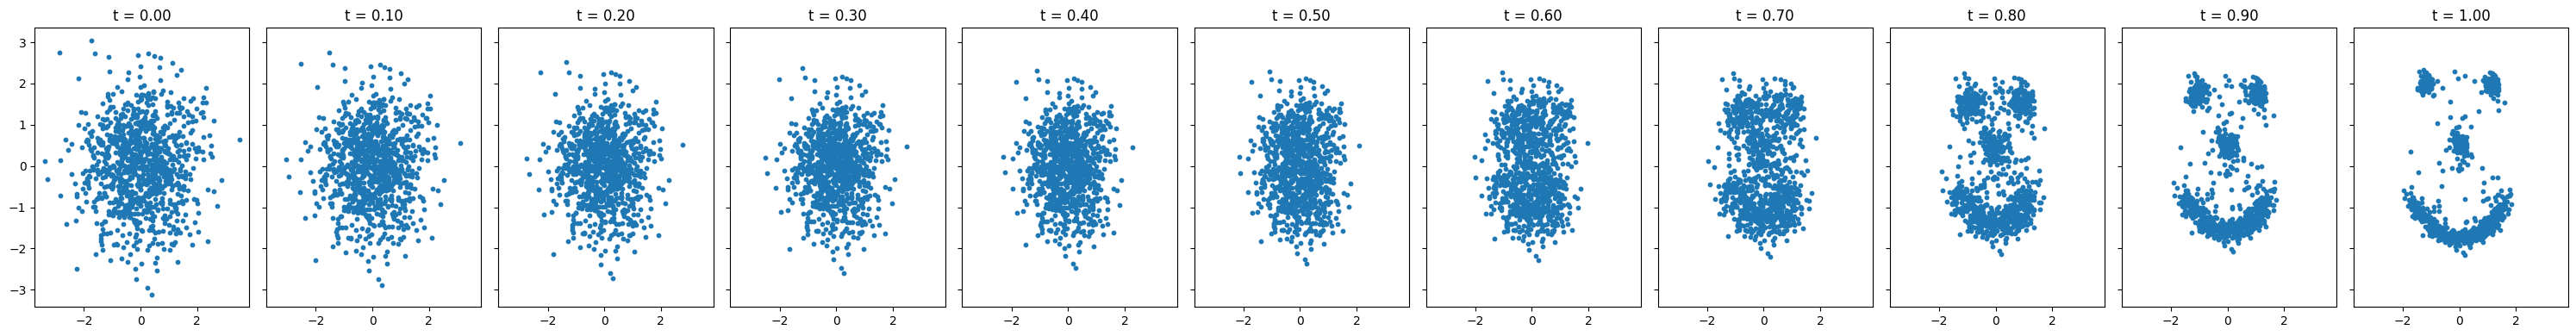

C:\Users\minhq\AppData\Local\Temp\ipykernel_25900\3081176186.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x_np[idx, 0], x_np[idx, 1], s=20, cmap='Set1', label='Target X', zorder=3)


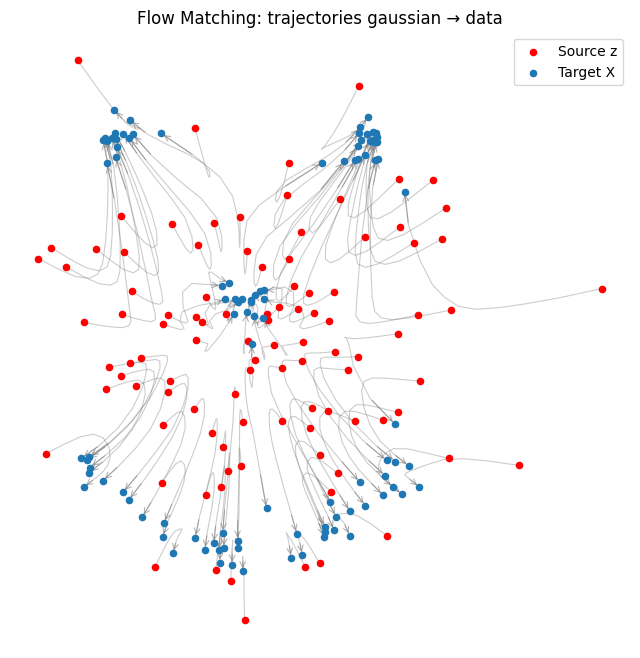

In [7]:
x = torch.randn(1000, 2)
z = x.clone()
n_steps = 10
time_steps = torch.linspace(0, 1.0, n_steps + 1)

trajectories = [x.clone()]

with torch.no_grad():
  for i in range(n_steps):
    x = net.step(x, time_steps[i], time_steps[i + 1])
    trajectories.append(x.clone())

trajectories = torch.stack(trajectories).numpy()  


fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
for t, ax in enumerate(axes):
    ax.scatter(trajectories[t, :, 0], trajectories[t, :, 1], s=10)
    ax.set_title(f't = {time_steps[t]:.2f}')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 8))

idx = np.random.choice(300, 100, replace=False)

for i in idx:
    traj = trajectories[:, i, :]         
    ax.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.4, lw=0.8)
    ax.annotate("",
      xy = traj[-1],
      xytext = traj[-2],
      arrowprops=dict(arrowstyle="->", color='gray', alpha=0.6, lw=0.8)
    )

z_np = z.numpy()
x_np = trajectories[-1]

ax.scatter(z_np[idx, 0], z_np[idx, 1], c='red',    s=20, label='Source z',  zorder=3)
ax.scatter(x_np[idx, 0], x_np[idx, 1], s=20, cmap='Set1', label='Target X', zorder=3)

ax.set_title("Flow Matching: trajectories gaussian → data")
ax.axis('off')
plt.legend()
plt.show()

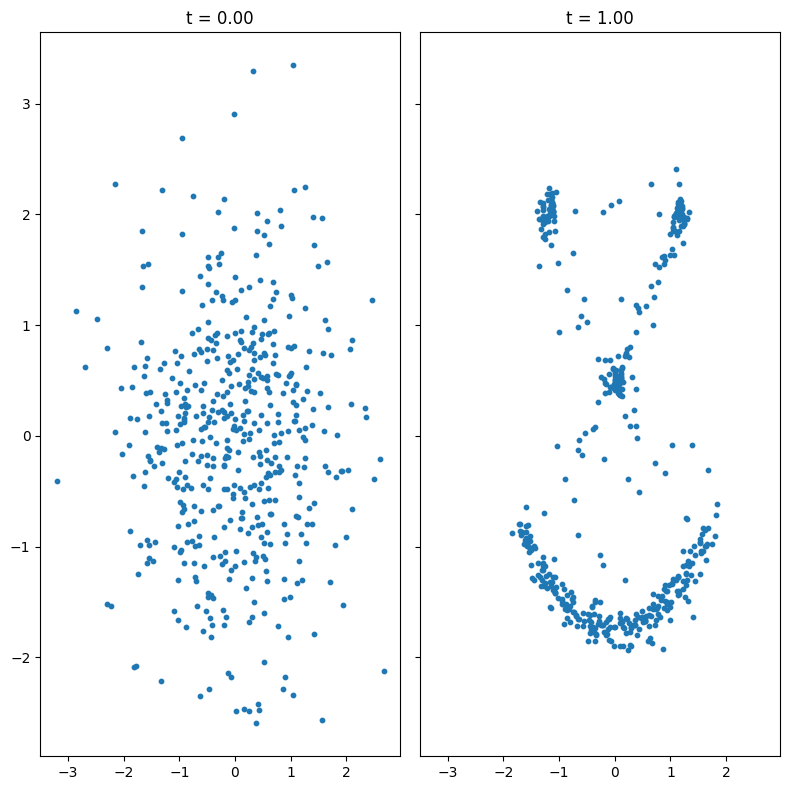

C:\Users\minhq\AppData\Local\Temp\ipykernel_25900\3747603590.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x_np[idx, 0], x_np[idx, 1],   s=20, cmap='Set1', label='Target X', zorder=3)


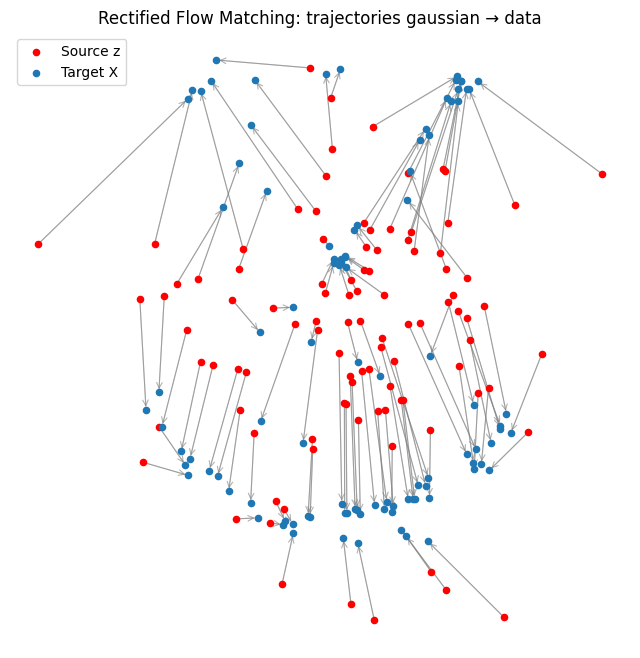

In [14]:
x = torch.randn(500, 2)
z = x.clone()
n_steps = 1
time_steps = torch.linspace(0, 1.0, n_steps + 1)

trajectories = [x.clone()]

with torch.no_grad():
  for i in range(n_steps):
    x = rectified_net.step(x, time_steps[i], time_steps[i + 1])
    trajectories.append(x.clone())

trajectories = torch.stack(trajectories).numpy()  


fig, axes = plt.subplots(1, n_steps + 1, figsize = (8, 8), sharex = True, sharey = True)
for t, ax in enumerate(axes):
    ax.scatter(trajectories[t, :, 0], trajectories[t, :, 1], s=10)
    ax.set_title(f't = {time_steps[t]:.2f}')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 8))

idx = np.random.choice(300, 100, replace=False)

for i in idx:
    traj = trajectories[:, i, :]         
    ax.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.4, lw=0.8)
    ax.annotate("",
      xy = traj[-1],
      xytext = traj[-2],
      arrowprops=dict(arrowstyle="->", color='gray', alpha=0.6, lw=0.8)
    )

z_np = z.numpy()
x_np = trajectories[-1]

ax.scatter(z_np[idx, 0], z_np[idx, 1], c='red',    s=20, label='Source z',  zorder=3)
ax.scatter(x_np[idx, 0], x_np[idx, 1],   s=20, cmap='Set1', label='Target X', zorder=3)

ax.set_title("Rectified Flow Matching: trajectories gaussian → data")
ax.axis('off')
plt.legend()
plt.show()